<a href="https://colab.research.google.com/github/harleyharry/DMV-Lab/blob/main/Company_Dataset_SD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/Companies_dataset.csv')

# Display the first 5 rows to understand the data structure
display(df.head())

,Unnamed: 0,name,ratings,review_count,ctype,years,hq,employees
0,0,TCS,3.8,(59.9k Reviews),Public,55 years old,"Mumbai,Maharashtra + 276 more",1 Lakh+ Employees (India)
1,1,Accenture,4.1,(38.3k Reviews),Public,34 years old,Dublin + 139 more,1 Lakh+ Employees (India)
2,2,Cognizant,3.9,(34.9k Reviews),Private,29 years old,Teaneck. New Jersey. + 109 more,1 Lakh+ Employees (India)
3,3,ICICI Bank,4.0,(28.5k Reviews),Public,29 years old,"Mumbai,Maharashtra + 1159 more",1 Lakh+ Employees (India)
4,4,Wipro,3.9,(28.4k Reviews),Public,78 years old,"Bangalore/Bengaluru,Karnataka + 235 more",1 Lakh+ Employees (India)


In [2]:
# Extract the primary headquarters location by splitting the 'hq' column
df['primary_hq'] = df['hq'].apply(lambda x: x.split(' + ')[0] if isinstance(x, str) else x)

# Display the top 10 most frequent primary headquarters locations
print("Top 10 Headquarters Locations:")
display(df['primary_hq'].value_counts().head(10))

Top 10 Headquarters Locations:


,count
primary_hq,
"Mumbai,Maharashtra",863
"Bangalore/Bengaluru,Karnataka",301
Mumbai,292
"Chennai,Tamil Nadu",279
"Gurgaon/Gurugram,Haryana",258
"Hyderabad/Secunderabad,Telangana",235
"Delhi/NCR,Delhi",215
"Noida,Uttar Pradesh",206
New Delhi,200


In [3]:
import numpy as np
import plotly.graph_objects as go

# Function to clean and convert review_count strings (e.g., '59.9k Reviews') to numbers
def clean_review_count(review_str):
    if isinstance(review_str, str):
        review_str = review_str.lower().replace(' reviews', '').replace('(', '').replace(')', '').strip()
        if 'k' in review_str:
            return float(review_str.replace('k', '')) * 1000
        else:
            return float(review_str)
    return np.nan

# Apply cleaning
df['review_count_numeric'] = df['review_count'].apply(clean_review_count)
df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce')

print("Data cleaned for review analysis.")

Data cleaned for review analysis.


In [4]:
# Define stages for the funnel based on rating thresholds
stages = [
    {'label': 'Total Companies', 'value': len(df)},
    {'label': 'Rated 3.0+', 'value': len(df[df['ratings'] >= 3.0])},
    {'label': 'Rated 3.5+', 'value': len(df[df['ratings'] >= 3.5])},
    {'label': 'Rated 4.0+', 'value': len(df[df['ratings'] >= 4.0])},
    {'label': 'Rated 4.5+', 'value': len(df[df['ratings'] >= 4.5])}
]

# Create the Funnel Chart
fig = go.Figure(go.Funnel(
    y = [s['label'] for s in stages],
    x = [s['value'] for s in stages],
    textinfo = "value+percent initial"))

fig.update_layout(title_text='Company Distribution by Rating Tier')
fig.show()

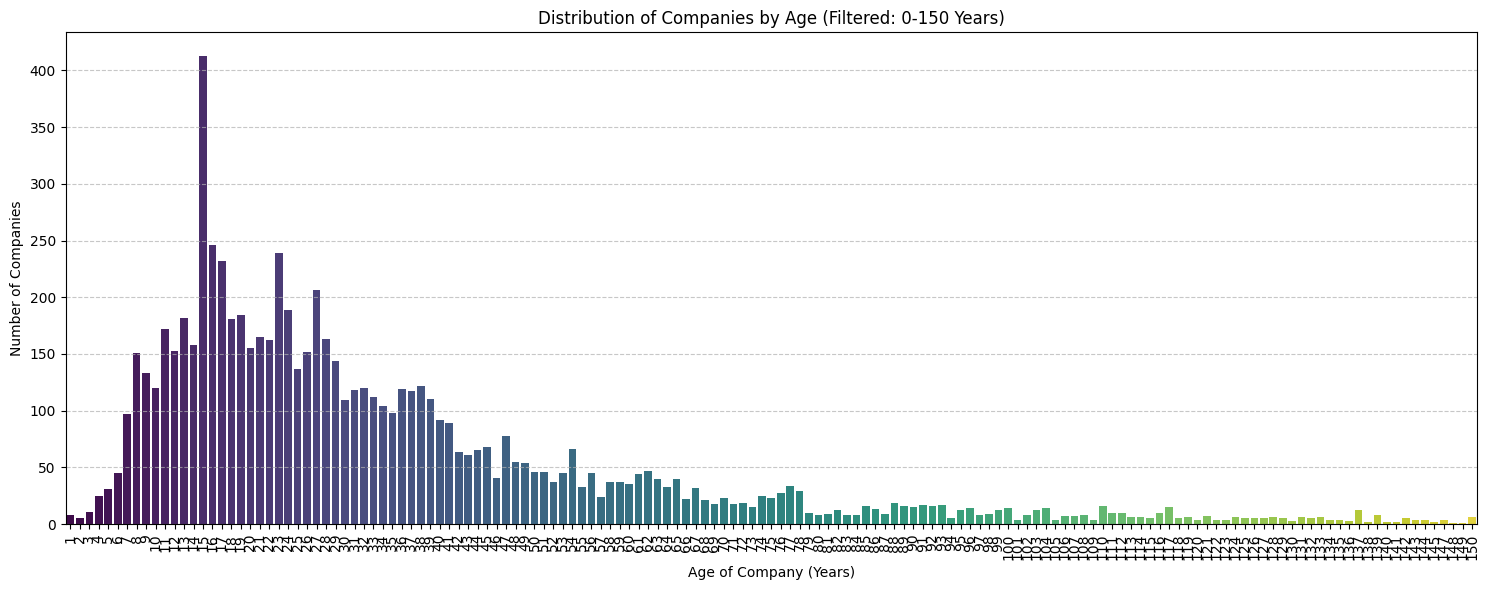

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to extract numeric years from strings like '55 years old'
def extract_years(year_str):
    if isinstance(year_str, str):
        # Extract digits from the string
        digits = ''.join(filter(str.isdigit, year_str))
        return int(digits) if digits else np.nan
    return np.nan

# Apply extraction
df['age_years'] = df['years'].apply(extract_years)

# Filter outliers: removing unrealistic ages (e.g., keeping companies <= 150 years old)
# This helps improve the visualization significantly
df_filtered = df[df['age_years'] <= 150].copy()

# Group by age and count companies
age_counts = df_filtered['age_years'].value_counts().sort_index()

# Create the bar chart
plt.figure(figsize=(15, 6))
sns.barplot(x=age_counts.index.astype(int), y=age_counts.values, hue=age_counts.index.astype(int), palette='viridis', legend=False)
plt.title('Distribution of Companies by Age (Filtered: 0-150 Years)')
plt.xlabel('Age of Company (Years)')
plt.ylabel('Number of Companies')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

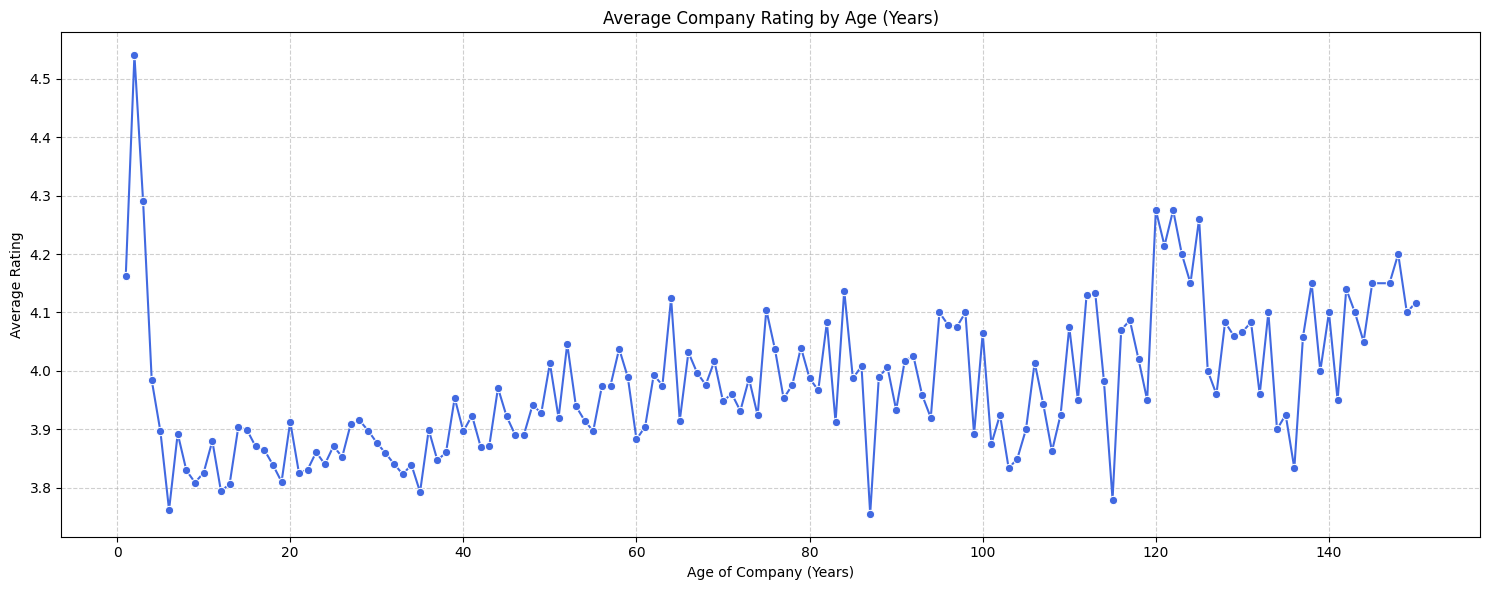

In [8]:
# Group by age and calculate mean rating
rating_by_age = df_filtered.groupby('age_years')['ratings'].mean().reset_index()

# Create the line chart
plt.figure(figsize=(15, 6))
sns.lineplot(data=rating_by_age, x='age_years', y='ratings', marker='o', color='royalblue')

plt.title('Average Company Rating by Age (Years)')
plt.xlabel('Age of Company (Years)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

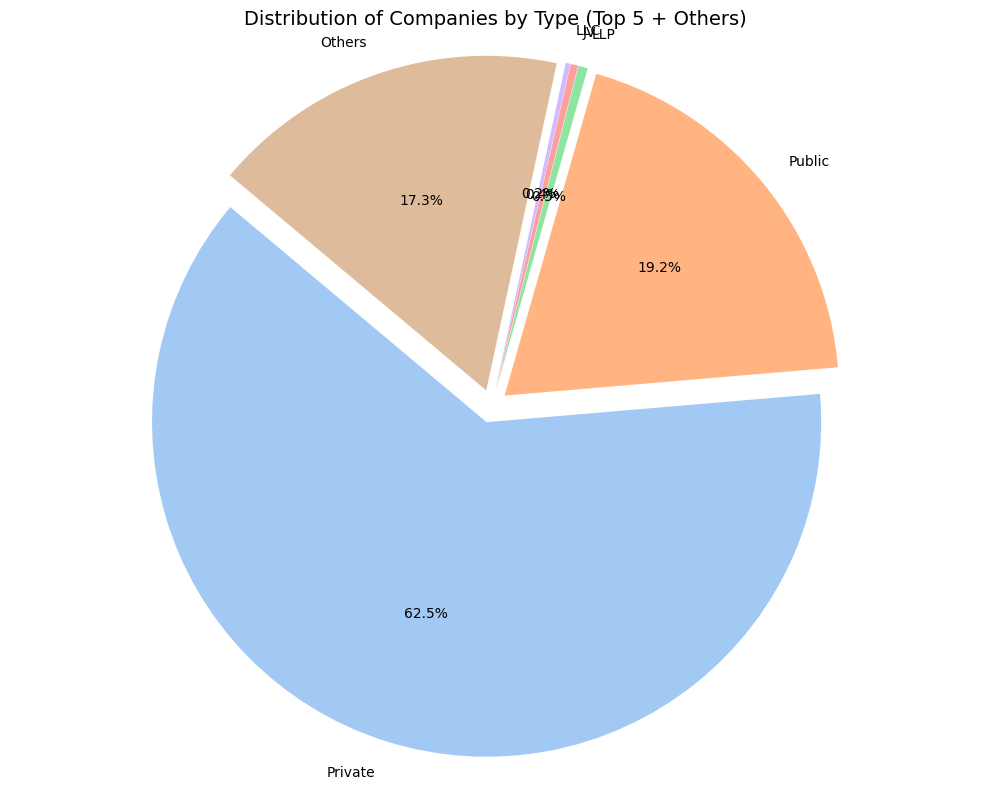

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the frequency counts of each company type
ctype_counts = df['ctype'].value_counts()

# Keep the top 5 categories and group the rest into 'Others'
top_n = 5
ctype_top = ctype_counts.head(top_n).copy()
ctype_top['Others'] = ctype_counts.iloc[top_n:].sum()

# Create a more readable pie chart
plt.figure(figsize=(10, 8))
plt.pie(ctype_top, labels=ctype_top.index, autopct='%1.1f%%', startangle=140,
        colors=sns.color_palette('pastel'), explode=[0.05]*len(ctype_top))

plt.title('Distribution of Companies by Type (Top 5 + Others)', fontsize=14)
plt.axis('equal')
plt.tight_layout()
plt.show()

### Re-analysis of Top 10 Companies

In [11]:
# Create a subset of only the first 10 companies
df_top10 = df.head(10).copy()
display(df_top10)

,Unnamed: 0,name,ratings,review_count,ctype,years,hq,employees,primary_hq,review_count_numeric,age_years
0,0,TCS,3.8,(59.9k Reviews),Public,55 years old,"Mumbai,Maharashtra + 276 more",1 Lakh+ Employees (India),"Mumbai,Maharashtra",59900.0,55.0
1,1,Accenture,4.1,(38.3k Reviews),Public,34 years old,Dublin + 139 more,1 Lakh+ Employees (India),Dublin,38300.0,34.0
2,2,Cognizant,3.9,(34.9k Reviews),Private,29 years old,Teaneck. New Jersey. + 109 more,1 Lakh+ Employees (India),Teaneck. New Jersey.,34900.0,29.0
3,3,ICICI Bank,4.0,(28.5k Reviews),Public,29 years old,"Mumbai,Maharashtra + 1159 more",1 Lakh+ Employees (India),"Mumbai,Maharashtra",28500.0,29.0
4,4,Wipro,3.9,(28.4k Reviews),Public,78 years old,"Bangalore/Bengaluru,Karnataka + 235 more",1 Lakh+ Employees (India),"Bangalore/Bengaluru,Karnataka",28400.0,78.0
5,5,HDFC Bank,3.9,(27.8k Reviews),Public,29 years old,"Mumbai,Maharashtra + 1390 more",1 Lakh+ Employees (India),"Mumbai,Maharashtra",27800.0,29.0
6,6,Infosys,3.9,(26.1k Reviews),Public,42 years old,"Bengaluru/Bangalore,Karnataka + 132 more",1 Lakh+ Employees (India),"Bengaluru/Bangalore,Karnataka",26100.0,42.0
7,7,Capgemini,3.9,(24.4k Reviews),Public,56 years old,Paris + 81 more,1 Lakh+ Employees (India),Paris,24400.0,56.0
8,8,Tech Mahindra,3.7,(22.8k Reviews),Public,37 years old,"Pune,Maharashtra + 221 more",1 Lakh+ Employees (India),"Pune,Maharashtra",22800.0,37.0
9,9,Genpact,4.0,(22.1k Reviews),Public,26 years old,"New York,New York + 76 more",1 Lakh+ Employees (India),"New York,New York",22100.0,26.0


In [12]:
# 1. Headquarters Analysis for Top 10
print("Headquarters for Top 10 Companies:")
display(df_top10['primary_hq'].value_counts())

Headquarters for Top 10 Companies:


,count
primary_hq,
"Mumbai,Maharashtra",3
Dublin,1
Teaneck. New Jersey.,1
"Bangalore/Bengaluru,Karnataka",1
"Bengaluru/Bangalore,Karnataka",1
Paris,1
"Pune,Maharashtra",1
"New York,New York",1


In [13]:
# 2. Rating Funnel for Top 10
stages_10 = [
    {'label': 'Total', 'value': len(df_top10)},
    {'label': 'Rated 3.5+', 'value': len(df_top10[df_top10['ratings'] >= 3.5])},
    {'label': 'Rated 4.0+', 'value': len(df_top10[df_top10['ratings'] >= 4.0])}
]

fig_10 = go.Figure(go.Funnel(
    y = [s['label'] for s in stages_10],
    x = [s['value'] for s in stages_10],
    textinfo = "value+percent initial"))

fig_10.update_layout(title_text='Rating Distribution (Top 10)')
fig_10.show()

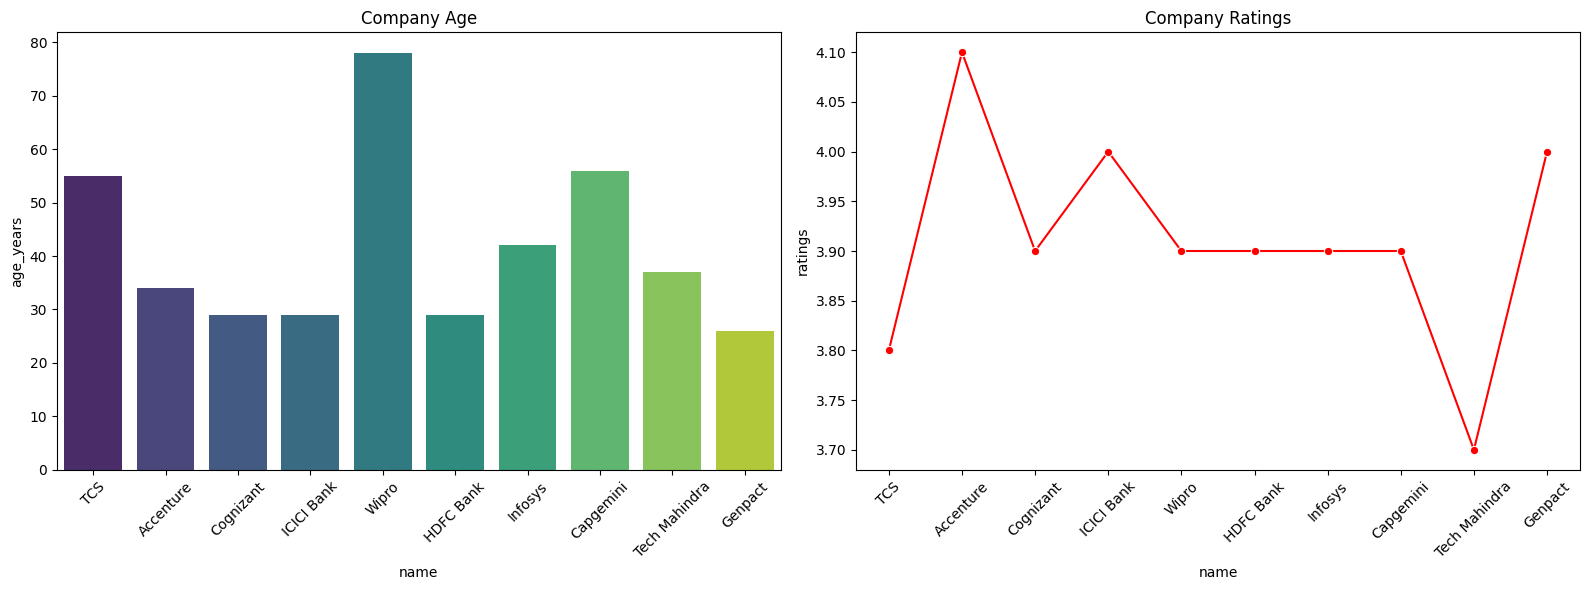

In [14]:
# 3. Age Distribution and Average Rating for Top 10
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x=df_top10['name'], y=df_top10['age_years'], ax=ax1, palette='viridis', hue=df_top10['name'], legend=False)
ax1.set_title('Company Age')
ax1.tick_params(axis='x', rotation=45)

sns.lineplot(x=df_top10['name'], y=df_top10['ratings'], ax=ax2, marker='o', color='red')
ax2.set_title('Company Ratings')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

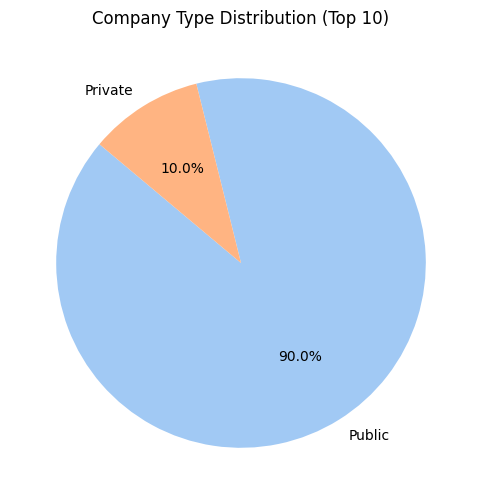

In [15]:
# 4. Company Type Pie Chart for Top 10
ctype_10 = df_top10['ctype'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(ctype_10, labels=ctype_10.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Company Type Distribution (Top 10)')
plt.show()